# NOAA Lightning Strike Analysis
### Working with missing data on a dataset

For this project, two datasets will be combined into a single dataframe that has information from both. Ideally, both datasets will have the same number of entries for the same locations on the same dates. The focus of this project will be to explore and identify any data that is missing.

In [1]:
# Import
import pandas as pd
import numpy as np
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Load
df1 = pd.read_csv('data/eda_missing_data_dataset1.csv')
df2 = pd.read_csv('data/eda_missing_data_dataset2.csv')

In [3]:
# df1 view
print(f"✅ Dataset loaded: {df1.shape[0]:,} rows × {df1.shape[1]} columns")
df1.head()

✅ Dataset loaded: 717,530 rows × 5 columns


,date,center_point_geom,longitude,latitude,number_of_strikes
0,2018-08-01,POINT(-81.6 22.6),-81.6,22.6,48
1,2018-08-01,POINT(-81.1 22.6),-81.1,22.6,32
2,2018-08-01,POINT(-80.9 22.6),-80.9,22.6,118
3,2018-08-01,POINT(-80.8 22.6),-80.8,22.6,69
4,2018-08-01,POINT(-98.4 22.8),-98.4,22.8,44


In [17]:
# df2 view
print(f"✅ Dataset loaded: {df2.shape[0]:,} rows × {df2.shape[1]} columns")
df2.head()

✅ Dataset loaded: 323,700 rows × 7 columns


,date,zip_code,city,state,state_code,center_point_geom,number_of_strikes
0,2018-08-08,3281,Weare,New Hampshire,NH,POINT(-71.7 43.1),1
1,2018-08-14,6488,Heritage Village CDP,Connecticut,CT,POINT(-73.2 41.5),3
2,2018-08-16,97759,"Sisters city, Black Butte Ranch CDP",Oregon,OR,POINT(-121.4 44.3),3
3,2018-08-18,6776,New Milford CDP,Connecticut,CT,POINT(-73.4 41.6),48
4,2018-08-08,1077,Southwick,Massachusetts,MA,POINT(-72.8 42),2


### Insight
- The first dataset has two unique columns `longitude` and `latitude`, while the second dataset has three unique columns `zip_code`, `city`, `state`, and `state_code`. Between the two, `date`, `center_point_geom`, and `number_of_strikes` are consistent

- The first dataset has more than double the number of rows as the second dataset. Merging datasets will help address this

In [4]:
# left-join merge
df_joined = df1.merge(df2, how='left', on=['date', 'center_point_geom'])

# Check
df_joined.head()

,date,center_point_geom,longitude,latitude,number_of_strikes_x,zip_code,city,state,state_code,number_of_strikes_y
0,2018-08-01,POINT(-81.6 22.6),-81.6,22.6,48,NaN,NaN,NaN,NaN,NaN
1,2018-08-01,POINT(-81.1 22.6),-81.1,22.6,32,NaN,NaN,NaN,NaN,NaN
2,2018-08-01,POINT(-80.9 22.6),-80.9,22.6,118,NaN,NaN,NaN,NaN,NaN
3,2018-08-01,POINT(-80.8 22.6),-80.8,22.6,69,NaN,NaN,NaN,NaN,NaN
4,2018-08-01,POINT(-98.4 22.8),-98.4,22.8,44,NaN,NaN,NaN,NaN,NaN


### Insights

- `date` and `center_point_geom` are used as keys as they are stable and identifying while the third consistent column between the two datasets, `number_of_strikes` is left unmentioned as this feature is potentially noisy

- Because `number_of_strikes` is not referenced as a key, Pandas creates two columns called `number_of_strikes_x` and `number_of_strikes_y` taken from their respective datasets

In [5]:
# Joined dataframe statistics
df_joined.describe()

,longitude,latitude,number_of_strikes_x,zip_code,number_of_strikes_y
count,717530.000000,717530.000000,717530.000000,323700.000000,323700.000000
mean,-90.875445,33.328572,21.637081,57931.958996,25.410587
std,13.648429,7.938831,48.029525,22277.327411,57.421824
min,-133.900000,16.600000,1.000000,1002.000000,1.000000
25%,-102.800000,26.900000,3.000000,38260.750000,3.000000
50%,-90.300000,33.200000,6.000000,59212.500000,8.000000
75%,-80.900000,39.400000,21.000000,78642.000000,24.000000
max,-43.800000,51.700000,2211.000000,99402.000000,2211.000000


In [8]:
# Df of just rows missing data
df_null_geo = df_joined[pd.isnull(df_joined.state_code)]
df_null_geo.shape

(393830, 10)

In [6]:
# Non-null count
df_joined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 717530 entries, 0 to 717529
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 717530 non-null  object 
 1   center_point_geom    717530 non-null  object 
 2   longitude            717530 non-null  float64
 3   latitude             717530 non-null  float64
 4   number_of_strikes_x  717530 non-null  int64  
 5   zip_code             323700 non-null  float64
 6   city                 323700 non-null  object 
 7   state                323700 non-null  object 
 8   state_code           323700 non-null  object 
 9   number_of_strikes_y  323700 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 54.7+ MB


### Insights 

- Left join kept all 717,530 rows
- Only 323,700 had matches in `df2`
- 393,830 rows couldn't be matched -> NaNs
- `df_null_geo` isolates exactly those unmatched rows

In [9]:
df_null_geo.head()

,date,center_point_geom,longitude,latitude,number_of_strikes_x,zip_code,city,state,state_code,number_of_strikes_y
0,2018-08-01,POINT(-81.6 22.6),-81.6,22.6,48,NaN,NaN,NaN,NaN,NaN
1,2018-08-01,POINT(-81.1 22.6),-81.1,22.6,32,NaN,NaN,NaN,NaN,NaN
2,2018-08-01,POINT(-80.9 22.6),-80.9,22.6,118,NaN,NaN,NaN,NaN,NaN
3,2018-08-01,POINT(-80.8 22.6),-80.8,22.6,69,NaN,NaN,NaN,NaN,NaN
4,2018-08-01,POINT(-98.4 22.8),-98.4,22.8,44,NaN,NaN,NaN,NaN,NaN


In [10]:
# Selecting features and grouping by latitude and longitude
top_missing = df_null_geo[['latitude', 'longitude', 'number_of_strikes_x']] \
    .groupby(['latitude', 'longitude']) \
    .sum() \
    .sort_values('number_of_strikes_x', ascending=False) \
    .reset_index()
top_missing.head(10)

,latitude,longitude,number_of_strikes_x
0,22.4,-84.2,3841
1,22.9,-82.9,3184
2,22.4,-84.3,2999
3,22.9,-83.0,2754
4,22.5,-84.1,2746
5,22.5,-84.2,2738
6,22.3,-81.0,2680
7,22.9,-82.4,2652
8,22.9,-82.3,2618
9,22.3,-84.3,2551


### Insights

#### Debugging through data aggregation
`zip` and `state` are unreliable features in this dataframe, instead lightning strikes are summed showing the most important missing locations first (`.sort_values(..., ascending=False)`)

## Visualization

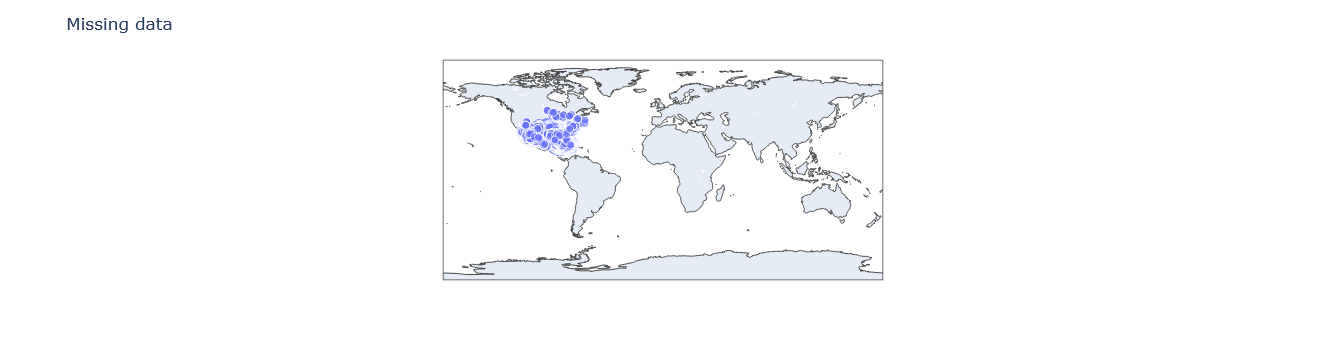

In [11]:
# Db reduction to prevent breeaking when plotting
fig = px.scatter_geo(top_missing[top_missing.number_of_strikes_x>=300],
                     lat="latitude",
                     lon="longitude",
                     size="number_of_strikes_x")
fig.update_layout(
    title_text = 'Missing data',
)

fig.show()

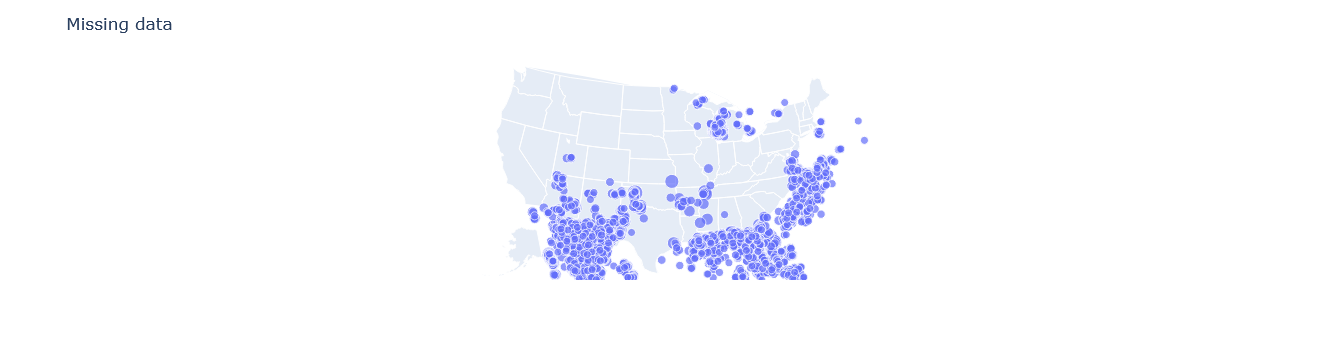

In [12]:
# Downscaling
fig = px.scatter_geo(top_missing[top_missing.number_of_strikes_x>=300],
                     lat="latitude",
                     lon="longitude",
                     size="number_of_strikes_x")
fig.update_layout(
    title_text = 'Missing data',
    geo_scope='usa',
)

fig.show()

## Key Insights

- Missing data is mostly expected over the ocean or non-U.S. locations with some locations inland missing zip/state which can be discussed with database owners